In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

/Users/sophie/Seaglider/SeagliderData/DataManagement


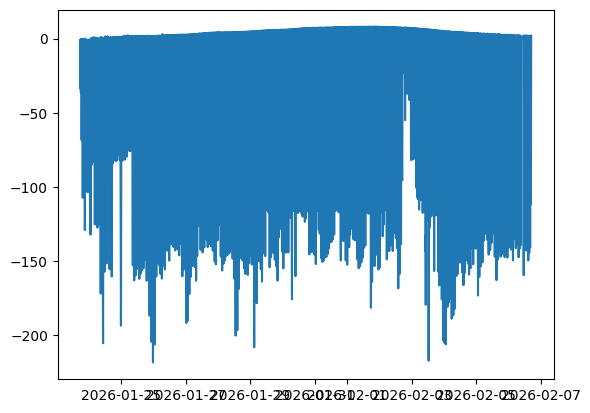

In [2]:
print(os.getcwd())
times_ds = xr.open_dataset('sg175_Jan_2026_UW_OTTER_(SG175)_timeseries.nc')
#display(times_ds)
times_ds.time.values[0]
times_ds['time'][0].values #same thing

time = times_ds.time.values
depth = times_ds.depth.values
plt.plot(time, -depth)

In [3]:
display(times_ds)

<xarray.Dataset> Size: 17MB
Dimensions:                                   (gps_info: 1239,
                                               sg_data_point: 90426,
                                               trajectory: 413, dive: 413)
Coordinates:
    ctd_time                                  (sg_data_point) datetime64[ns] 723kB ...
    ctd_depth                                 (sg_data_point) float32 362kB ...
    latitude                                  (sg_data_point) float32 362kB ...
    longitude                                 (sg_data_point) float32 362kB ...
  * trajectory                                (trajectory) int32 2kB 1 2 ... 415
Dimensions without coordinates: gps_info, sg_data_point, dive
Data variables: (12/67)
    gps_info_dive_number                      (gps_info) int32 5kB ...
    sg_data_point_dive_number                 (sg_data_point) int32 362kB ...
    log_gps_time                              (gps_info) datetime64[ns] 10kB ...
    time                                      (sg_data_point) datetime64[ns] 723kB ...
    pressure                                  (sg_data_point) float32 362kB ...
    depth                                     (sg_data_point) float32 362kB 1...
    ...                                        ...
    end_longitude                             (dive) float32 2kB ...
    depth_avg_curr_east                       (dive) float32 2kB ...
    depth_avg_curr_north                      (dive) float32 2kB ...
    depth_avg_curr_qc                         (dive) |S1 413B ...
    latlong_qc                                (dive) |S1 413B ...
    glider                                    |S12 12B ...
Attributes: (12/47)
    project:                         Jan 2026 Shilshole Test Deployment (SG175)
    title:                           Physical, chemical, and biological data ...
    summary:                         SG175 Jan 2026 Shilshole Test Deployment...
    source:                          Seaglider SG175
    references:                      http://data.nodc.noaa.gov/accession/0092291
    processing_level:                1.12
    ...                              ...
    date_modified:                   2026-02-10T03:02:46Z
    uuid:                            e33e943e-0630-11f1-8dd8-e3cb84ffd70c
    base_station_version:            3.0.6
    base_station_micro_version:      0
    quality_control_version:         1.12
    Conventions:                     CF-1.6

In [4]:
#times_ds = xr.open_dataset('sg194_May_2025_UW_OTTER_(SG194)_timeseries.nc')

depth = times_ds.depth.values
dive_ids = times_ds.sg_data_point_dive_number.values

# stores the corrected depth
depth_corrected = depth.copy()

# unique dives in order
unique_dives = sorted(set(dive_ids))

# loop to get and apply offset
for d in unique_dives:
    # indices in sg_data_point belonging to this dive
    idx = (dive_ids == d)

    # first depth measurement in this dive
    offset = depth[idx][0]

    # apply correction
    depth_corrected[idx] = depth[idx] - offset

times_ds["depth_corrected"] = (("sg_data_point",), depth_corrected)

depth_sg = times_ds['depth']
time_sg = times_ds['time']

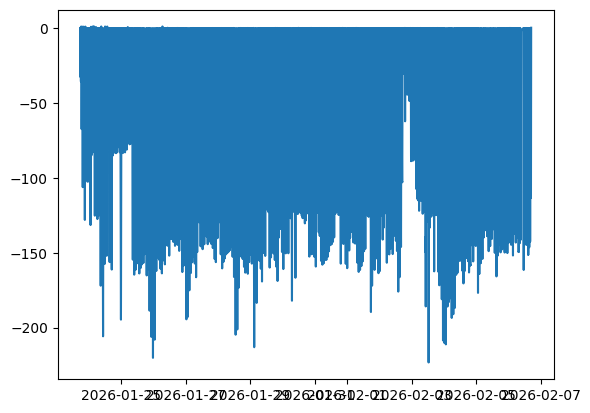

In [6]:
plt.plot(time, -depth_corrected)

In [7]:
print(os.getcwd())
#Load the dataset


#Align time with sg_data_point and apply offset (if needed)
adjusted_time = pd.to_datetime(times_ds['time'].values) + pd.DateOffset(years=0, months=0, days=0)

times_ds['PAR_470nm'] = times_ds['eng_wlbb2fl_sig470nm']
times_ds['particle_concentration_700nm'] = times_ds['eng_wlbb2fl_sig700nm']
times_ds['chlorophyll_695nm'] = times_ds['eng_wlbb2fl_sig695nm']
times_ds['dissolved_oxygen'] = times_ds['aanderaa4330_dissolved_oxygen']
times_ds['instrument_dissolved_oxygen'] = times_ds['aanderaa4330_instrument_dissolved_oxygen']

# add metadata
times_ds['PAR_470nm'].attrs['pre_cleaning_name'] = 'eng_wlbb2fl_sig470nm'
times_ds['particle_concentration_700nm'].attrs['pre_cleaning_name'] = 'eng_wlbb2fl_sig700nm'
times_ds['chlorophyll_695nm'].attrs['pre_cleaning_name'] = 'eng_wlbb2fl_sig695nm'
times_ds['dissolved_oxygen'].attrs['pre_cleaning_name'] = 'aanderaa4330_dissolved_oxygen'
times_ds['instrument_dissolved_oxygen'].attrs['pre_cleaning_name'] = 'aanderaa4330_dissolved_oxygen'

times_ds = times_ds.assign_coords(time=('sg_data_point', adjusted_time))

#Select the relevant variables
new_times_ds = times_ds[['time', 'depth_corrected', 'latitude', 'longitude','temperature', 'salinity', 'dissolved_oxygen', 'instrument_dissolved_oxygen', 'PAR_470nm', 'particle_concentration_700nm', 'chlorophyll_695nm']]

#Convert to DataFrame and save
new_times_ds.to_dataframe().reset_index().to_csv('sg175_Jan_2026_UW_OTTER_(SG175)_timeseries_cleaned.csv', index=False)
new_times_ds.to_netcdf('sg175_Jan_2026_UW_OTTER_(SG175)_timeseries_cleaned.nc')
display(new_times_ds)

/Users/sophie/Seaglider/SeagliderData/DataManagement


<xarray.Dataset> Size: 5MB
Dimensions:                       (sg_data_point: 90426)
Coordinates:
    time                          (sg_data_point) datetime64[ns] 723kB 2026-0...
    latitude                      (sg_data_point) float32 362kB 47.83 ... 47.85
    longitude                     (sg_data_point) float32 362kB -122.4 ... -1...
    ctd_time                      (sg_data_point) datetime64[ns] 723kB 2026-0...
    ctd_depth                     (sg_data_point) float32 362kB 0.5136 ... -1...
Dimensions without coordinates: sg_data_point
Data variables:
    depth_corrected               (sg_data_point) float32 362kB 0.0 ... -0.2096
    temperature                   (sg_data_point) float32 362kB 9.074 ... 9.676
    salinity                      (sg_data_point) float32 362kB nan nan ... nan
    dissolved_oxygen              (sg_data_point) float32 362kB nan nan ... nan
    instrument_dissolved_oxygen   (sg_data_point) float32 362kB nan nan ... nan
    PAR_470nm                     (sg_data_point) float32 362kB 349.0 ... 468.0
    particle_concentration_700nm  (sg_data_point) float32 362kB 161.0 ... 181.0
    chlorophyll_695nm             (sg_data_point) float32 362kB 116.0 ... 114.0
Attributes: (12/47)
    project:                         Jan 2026 Shilshole Test Deployment (SG175)
    title:                           Physical, chemical, and biological data ...
    summary:                         SG175 Jan 2026 Shilshole Test Deployment...
    source:                          Seaglider SG175
    references:                      http://data.nodc.noaa.gov/accession/0092291
    processing_level:                1.12
    ...                              ...
    date_modified:                   2026-02-10T03:02:46Z
    uuid:                            e33e943e-0630-11f1-8dd8-e3cb84ffd70c
    base_station_version:            3.0.6
    base_station_micro_version:      0
    quality_control_version:         1.12
    Conventions:                     CF-1.6

In [8]:
times_ds.time.values[0]

np.datetime64('2026-01-23T17:34:40.720999936')

In [35]:
times_ds = xr.open_dataset('sg194_May_2025_UW_OTTER_(SG194)_timeseries.nc')

#Apply time apply offset (if needed)
adjusted_time = pd.to_datetime(times_ds['time'].values) + pd.DateOffset(years=0, months=0, days=0)

times_ds['U_DAC'] = times_ds['depth_avg_curr_east']
times_ds['V_DAC'] = times_ds['depth_avg_curr_north']

# add metadata
times_ds['U_DAC'].attrs['pre_cleaning_name'] = 'depth_avg_curr_east'
times_ds['V_DAC'].attrs['pre_cleaning_name'] = 'depth_avg_curr_north'

#Select the relevant variables
new_times_ds = times_ds[['U_DAC', 'V_DAC', 'start_time', 'end_time', 'start_latitude', 'end_latitude', 'start_longitude', 'end_longitude']]
display(new_times_ds)

#Convert to DataFrame and save
new_times_ds.to_dataframe().reset_index().to_csv('sg194_May_2025_UW_OTTER_(SG194)_DAC_timeseries_cleaned.csv', index=False)
new_times_ds.to_netcdf('sg194_May_2025_UW_OTTER_(SG194)_DAC_timeseries_cleaned.nc')


<xarray.Dataset> Size: 16kB
Dimensions:          (dive: 389)
Dimensions without coordinates: dive
Data variables:
    U_DAC            (dive) float32 2kB ...
    V_DAC            (dive) float32 2kB ...
    start_time       (dive) datetime64[ns] 3kB ...
    end_time         (dive) datetime64[ns] 3kB ...
    start_latitude   (dive) float32 2kB ...
    end_latitude     (dive) float32 2kB ...
    start_longitude  (dive) float32 2kB ...
    end_longitude    (dive) float32 2kB ...
Attributes: (12/47)
    project:                         May 2025 UW OTTER (SG194)
    title:                           Physical, chemical, and biological data ...
    summary:                         SG194 May 2025 UW OTTER (SG194)
    source:                          Seaglider SG194
    references:                      http://data.nodc.noaa.gov/accession/0092291
    processing_level:                1.12
    ...                              ...
    date_modified:                   2025-06-13T17:06:17Z
    uuid:                            e9774cfa-487c-11f0-80b3-07c04838153a
    base_station_version:            3.0.2
    base_station_micro_version:      0
    quality_control_version:         1.12
    Conventions:                     CF-1.6